# W1-D2: Khai phá log, parse log và phát hiện bất thường

Notebook này bám đúng yêu cầu bài tập: dùng HDFS từ Loghub, parse template, đếm tần suất, phát hiện spike/new template, và làm mini log analyzer.

## 0. Cài thư viện cần thiết

Nếu máy bạn chưa có các thư viện bên dưới, hãy chạy cell này trước. Notebook được viết để ai tải repo về cũng có thể cài và chạy được.

In [1]:
# Chay 1 lan de cai day du thu vien cho notebook
%pip install --break-system-packages pandas numpy matplotlib seaborn scikit-learn drain3 ipykernel

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import subprocess

requirements = [
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scikit-learn", "sklearn"),
    ("drain3", "drain3"),
]

for pip_name, import_name in requirements:
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--break-system-packages",
            pip_name,
        ])

print("Da kiem tra/cai xong thu vien can thiet.")

Da kiem tra/cai xong thu vien can thiet.


## 1. Khởi tạo môi trường làm việc

In [3]:
import sys
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'w1' / 'd2').exists():
        ROOT = candidate
        break

D2 = ROOT / 'w1' / 'd2'
sys.path.insert(0, str(D2))

from d2_pipeline import *

OUT = D2 / 'artifacts' / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)
print('ROOT =', ROOT)
print('D2 =', D2)
print('DRAIN3_AVAILABLE =', DRAIN3_AVAILABLE)

ROOT = d:\AWS\AIOPS
D2 = d:\AWS\AIOPS\w1\d2
DRAIN3_AVAILABLE = True


## 2. Dữ liệu HDFS từ Loghub

Bộ dữ liệu dùng trong bài:

- `data/raw/HDFS_100k.log_structured.csv`
- `data/raw/anomaly_label.csv`

Nếu bạn muốn thử lại với dataset khác từ Loghub, chỉ cần đổi đường dẫn ở cell này.

In [4]:
log_path = D2 / 'data' / 'raw' / 'HDFS_100k.log_structured.csv'
label_path = D2 / 'data' / 'raw' / 'anomaly_label.csv'

df = load_hdfs_structured(log_path, label_path)
print('Tổng số dòng log =', len(df))
print('Số block_id =', df['block_id'].nunique())
print('Tỷ lệ anomaly =', round(df['label'].mean(), 4))
display(df.head(3))

Tổng số dòng log = 104815
Số block_id = 7940
Tỷ lệ anomaly = 0.0312


,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate,block_id,label
0,1,81109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,E5,Receiving block <*> src: /<*> dest: /<*>,blk_-1608999687919862906,0
1,2,81109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,E22,BLOCK* NameSystem.allocateBlock:<*>,blk_-1608999687919862906,0
2,3,81109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,E5,Receiving block <*> src: /<*> dest: /<*>,blk_-1608999687919862906,0


## 3. Phase 1 - Parse log với Drain3

Trong môi trường này, pipeline sẽ ưu tiên Drain3. Nếu máy cài chưa sẵn `drain3`, notebook vẫn có fallback để chạy được end-to-end.

In [5]:
parsed = [ParsedEntry(raw=row.Content, timestamp=None, template=row.EventTemplate, template_id=row.EventId) for row in df.itertuples()]
templates = summarize_templates(parsed)
top10 = templates.head(10).copy()
(ROOT / 'results').mkdir(parents=True, exist_ok=True)
top10.to_csv(ROOT / 'results' / 'top_templates.csv', index=False)
display(top10)

tuning = tune_similarity(df['Content'].astype(str).head(5000).tolist(), values=(0.3, 0.5, 0.7))
tuning.to_csv(OUT / 'tuning_log.csv', index=False)
display(tuning)

,template_id,template,count
0,E5,Receiving block <*> src: /<*> dest: /<*>,23671
1,E26,BLOCK* NameSystem.addStoredBlock: blockMap upd...,23478
2,E11,PacketResponder <*> for block <*> terminating,23451
3,E9,Received block <*> of size <*> from /<*>,23447
4,E22,BLOCK* NameSystem.allocateBlock:<*>,7940
5,E2,Verification succeeded for <*>,2183
6,E3,<*> Served block <*> to /<*>,407
7,E7,writeBlock <*> received exception <*>,68
8,E6,Received block <*> src: /<*> dest: /<*> of siz...,31
9,E16,<*>:Transmitted block <*> to /<*>,27


,sim_th,template_count,fallback
0,0.3,13,False
1,0.5,13,False
2,0.7,664,False


## 4. Phase 2 - Tạo time series và phát hiện bất thường

Với HDFS, mỗi block có thể coi như một session. Ta gộp theo `block_id` để tạo feature, rồi dùng detector để đánh dấu session bất thường.

,precision,recall,f1
0,0.966667,0.463259,0.62635


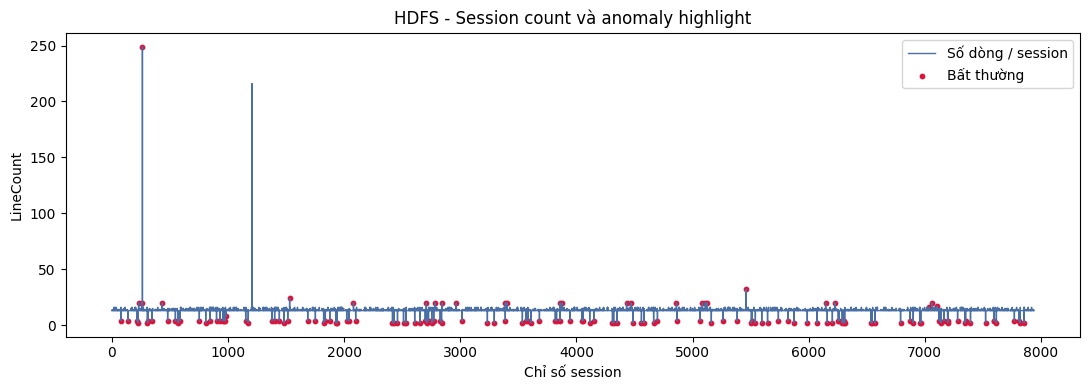

In [6]:
sess = hdfs_session_features(df)
feature_cols = [c for c in sess.columns if c.startswith('feat_')]
X = sess[feature_cols].astype(float)

clf = IsolationForest(contamination=max(sess['Label'].mean(), 0.01), random_state=42)
pred = (clf.fit_predict(X) == -1).astype(int)
sess['Pred'] = pred

metrics = evaluate_binary(sess['Label'], sess['Pred'])
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(OUT / 'hdfs_metrics.csv', index=False)
display(metrics_df)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sess.index, sess['LineCount'], color='#4a6fa5', linewidth=1, label='Số dòng / session')
ax.scatter(sess.index[sess['Pred'] == 1], sess.loc[sess['Pred'] == 1, 'LineCount'], color='crimson', s=10, label='Bất thường')
ax.set_title('HDFS - Session count và anomaly highlight')
ax.set_xlabel('Chỉ số session')
ax.set_ylabel('LineCount')
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'hdfs_anomaly_highlight.png', dpi=160)
plt.show()

## 5. Phase 3 - TF-IDF và phát hiện template mới

Ta dùng TF-IDF để đo độ giống nhau giữa các template. Sau đó inject một dòng log lạ để kiểm tra việc phát hiện template mới.

In [7]:
sim = tfidf_similarity(top10['template'])
display(sim)

injected = '[2026-06-01 11:11:11] CRITICAL quantum flux mismatch detected on node x9 from 172.16.9.9'
parsed_inj, meta_inj = parse_with_drain(df['Content'].astype(str).tolist() + [injected], sim_th=0.5)
print('Số template sau khi inject =', meta_inj['template_count'])
print('Dòng inject tạo template mới =', parsed_inj[-1].is_new_template)
print('Template của dòng inject =', parsed_inj[-1].template)

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.045735,0.070946,0.069689,0.087494,0.00000,0.091634,0.000000,0.542286,0.091634
1,0.045735,1.000000,0.043508,0.162699,0.250427,0.00000,0.213932,0.000000,0.151905,0.213932
2,0.070946,0.043508,1.000000,0.066297,0.083235,0.25631,0.087173,0.000000,0.061898,0.087173
3,0.069689,0.162699,0.066297,1.000000,0.081760,0.00000,0.085628,0.199003,0.625110,0.085628
4,0.087494,0.250427,0.083235,0.081760,1.000000,0.00000,0.107506,0.000000,0.076336,0.107506
5,0.000000,0.000000,0.256310,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000
6,0.091634,0.213932,0.087173,0.085628,0.107506,0.00000,1.000000,0.000000,0.079948,0.428634
7,0.000000,0.000000,0.000000,0.199003,0.000000,0.00000,0.000000,1.000000,0.185801,0.000000
8,0.542286,0.151905,0.061898,0.625110,0.076336,0.00000,0.079948,0.185801,1.000000,0.079948
9,0.091634,0.213932,0.087173,0.085628,0.107506,0.00000,0.428634,0.000000,0.079948,1.000000


Số template sau khi inject = 46
Dòng inject tạo template mới = True
Template của dòng inject = [2026-06-01 11:11:11] CRITICAL quantum flux mismatch detected on node x9 from 172.16.9.9


## 6. Phase 4 - Mini Log Analyzer

Chạy từ terminal:

```bash
python w1/d2/log_analyzer.py <logfile>
```

Script sẽ in ra:

- Tổng số dòng
- Số template unique
- Top-5 template theo count và tỷ lệ
- Template spike trong 1 giờ gần nhất
- New template trong 1 giờ gần nhất

## 7. Kết luận ngắn

- Drain3 phù hợp với log unstructured có mẫu lặp lại.
- Template mới thường là tín hiệu sớm cho lỗi mới hoặc thay đổi hành vi hệ thống.
- Metric nói cho mình biết "cái gì đang sai", log giúp trả lời "tại sao".

## 8. Bonus

M?c n?y so s?nh m?t log ?ng d?ng gi? l?p theo 3 c?ch: JSON structured, plain text unstructured, v? regex parser.

In [ ]:
docker_json_logs = [
    '{\"timestamp\":\"2026-06-01T10:00:01Z\",\"level\":\"INFO\",\"message\":\"GET /api/orders 200 12ms service=checkout user=U1\"}',
    '{\"timestamp\":\"2026-06-01T10:00:02Z\",\"level\":\"INFO\",\"message\":\"GET /api/orders 200 15ms service=checkout user=U2\"}',
    '{\"timestamp\":\"2026-06-01T10:00:03Z\",\"level\":\"ERROR\",\"message\":\"POST /api/payments 500 31ms service=checkout order=O99\"}',
    '{\"timestamp\":\"2026-06-01T10:00:04Z\",\"level\":\"WARN\",\"message\":\"GET /api/cart 429 8ms service=checkout user=U1\"}',
]

docker_plain_logs = [
    '2026-06-01 10:00:01 INFO GET /api/orders 200 12ms service=checkout user=U1',
    '2026-06-01 10:00:02 INFO GET /api/orders 200 15ms service=checkout user=U2',
    '2026-06-01 10:00:03 ERROR POST /api/payments 500 31ms service=checkout order=O99',
    '2026-06-01 10:00:04 WARN GET /api/cart 429 8ms service=checkout user=U1',
]

json_parsed = parse_json_log_lines(docker_json_logs)
plain_parsed, _ = parse_with_drain(docker_plain_logs, sim_th=0.5)
regex_parsed = parse_regex_log_lines(docker_plain_logs, r'^(?P<ts>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}) (?P<level>[A-Z]+) (?P<msg>.*)$')

print('JSON structured unique templates =', summarize_templates(json_parsed).shape[0])
print('Plain text Drain3 unique templates =', summarize_templates(plain_parsed).shape[0])
print('Regex parser unique templates =', summarize_templates(regex_parsed).shape[0])

comparison = compare_template_outputs(plain_parsed, regex_parsed)
display(comparison)

print('Nh?n x?t ng?n: JSON log th??ng ?t template h?n v? field ?? c? c?u tr?c; plain text c?n Drain3/regex ?? gom bi?n ??ng.')